# MNIST Image Recognition


This notebook trains and evaluates three neural network architectures on the MNIST handwritten digit dataset:
1. A shallow Multi-Layer Perceptron (MLP)
2. Convolutional Neural Network (CNN)
3. Transformer (Encoder)

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import math

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

import csv

BATCH_SIZE = 128
TUNE_EPOCHS = [10, 15, 20]
TUNE_LRS = [5e-4, 1e-3, 3e-3, 5e-3]

torch.manual_seed(42)

Using device: mps


## Load MNIST Data

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Train samples: 60000
Test samples:  10000


## Model 1: Shallow Multi-Layer Perceptron (MLP)

In [3]:
class ShallowMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Model 2: Convolutional Neural Network (CNN)

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Model 3: Transformer Encoder

In [5]:
class PatchEmbedding(nn.Module):
    """Split a 28x28 image into 4x4 patches and project to an embedding."""

    def __init__(self, patch_size=4, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        num_patches = (28 // patch_size) ** 2  # 49 patches for 4x4
        self.proj = nn.Conv2d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x)                        # (B, embed_dim, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)        # (B, num_patches, embed_dim)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)          # (B, num_patches+1, embed_dim)
        x = x + self.pos_embed
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, patch_size=4, embed_dim=64, num_heads=4, num_layers=2):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_size, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(embed_dim, 10)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        cls_out = x[:, 0]  # CLS token
        return self.head(cls_out)

## Training and Testing Functions

In [6]:
os.makedirs("logs", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)


def train_model(model, train_loader, test_loader, epochs, lr, csv_path, ckpt_path):
    """Train model, log train/test metrics per epoch to CSV, save checkpoint at end."""
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    log_rows = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        test_loss_sum, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss_sum += loss.item() * images.size(0)
                test_correct += (outputs.argmax(1) == labels).sum().item()
                test_total += labels.size(0)

        row = {
            "epoch": epoch,
            "train_loss": train_loss_sum / train_total,
            "train_acc": 100.0 * train_correct / train_total,
            "test_loss": test_loss_sum / test_total,
            "test_acc": 100.0 * test_correct / test_total,
        }
        log_rows.append(row)
        print(f"    Epoch {epoch:2d}/{epochs} | "
              f"Train Loss: {row['train_loss']:.4f}  Acc: {row['train_acc']:.2f}% | "
              f"Test  Loss: {row['test_loss']:.4f}  Acc: {row['test_acc']:.2f}%")

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "train_acc", "test_loss", "test_acc"])
        writer.writeheader()
        writer.writerows(log_rows)

    torch.save(model.state_dict(), ckpt_path)
    return log_rows[-1]["test_acc"]


def test_model(model, test_loader):
    """Evaluate model on test set, return overall accuracy and per-class accuracy."""
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    class_correct = [0] * 10
    class_total = [0] * 10

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            for label, pred in zip(labels, preds):
                class_total[label.item()] += 1
                if label == pred:
                    class_correct[label.item()] += 1

    overall_acc = 100.0 * correct / total
    per_class = {
        d: 100.0 * class_correct[d] / class_total[d] for d in range(10)
    }
    return overall_acc, per_class


def run_tuning(model_name, model_cls, train_loader, test_loader, epoch_list, lr_list):
    """Run all (lr, epoch) combos for a model class, return list of result dicts."""
    results = []
    total = len(epoch_list) * len(lr_list)
    run_idx = 0
    for epochs in epoch_list:
        for lr in lr_list:
            run_idx += 1
            tag = f"{model_name}_lr{lr:.0e}_ep{epochs}"
            csv_path = f"logs/{tag}.csv"
            ckpt_path = f"checkpoints/{tag}.pt"
            print(f"  [{run_idx}/{total}] {model_name} | lr={lr}, epochs={epochs}")
            model = model_cls().to(device)
            test_acc = train_model(model, train_loader, test_loader, epochs, lr, csv_path, ckpt_path)
            results.append({
                "model": model_name,
                "lr": lr,
                "epochs": epochs,
                "test_acc": test_acc,
                "csv": csv_path,
                "ckpt": ckpt_path,
            })
            print(f"    -> Test Acc: {test_acc:.2f}%\n")
    return results

## Hyperparameter Tuning (LR and Epochs)

Grid: epochs in {10, 15, 20}, lr in {5e-4, 1e-3, 3e-3, 5e-3}. 12 runs per model, 36 total.
Per-epoch metrics are saved to `logs/` and model checkpoints to `checkpoints/`.

In [8]:
print("=" * 60)
print("Tuning: Shallow MLP")
print("=" * 60)
mlp_results = run_tuning("mlp", ShallowMLP, train_loader, test_loader, TUNE_EPOCHS, TUNE_LRS)

Tuning: Shallow MLP
  [1/12] mlp | lr=0.0005, epochs=10
    Epoch  1/10 | Train Loss: 0.3343  Acc: 90.73% | Test  Loss: 0.1809  Acc: 94.64%
    Epoch  2/10 | Train Loss: 0.1483  Acc: 95.70% | Test  Loss: 0.1201  Acc: 96.36%
    Epoch  3/10 | Train Loss: 0.1004  Acc: 97.13% | Test  Loss: 0.0940  Acc: 97.24%
    Epoch  4/10 | Train Loss: 0.0757  Acc: 97.83% | Test  Loss: 0.0822  Acc: 97.58%
    Epoch  5/10 | Train Loss: 0.0598  Acc: 98.25% | Test  Loss: 0.0746  Acc: 97.67%
    Epoch  6/10 | Train Loss: 0.0483  Acc: 98.63% | Test  Loss: 0.0693  Acc: 97.92%
    Epoch  7/10 | Train Loss: 0.0385  Acc: 98.92% | Test  Loss: 0.0680  Acc: 97.89%
    Epoch  8/10 | Train Loss: 0.0317  Acc: 99.13% | Test  Loss: 0.0664  Acc: 97.91%
    Epoch  9/10 | Train Loss: 0.0254  Acc: 99.31% | Test  Loss: 0.0656  Acc: 97.95%
    Epoch 10/10 | Train Loss: 0.0211  Acc: 99.44% | Test  Loss: 0.0629  Acc: 98.04%
    -> Test Acc: 98.04%

  [2/12] mlp | lr=0.001, epochs=10
    Epoch  1/10 | Train Loss: 0.2679  Acc: 9

In [9]:
print("=" * 60)
print("Tuning: CNN")
print("=" * 60)
cnn_results = run_tuning("cnn", CNN, train_loader, test_loader, TUNE_EPOCHS, TUNE_LRS)

Tuning: CNN
  [1/12] cnn | lr=0.0005, epochs=10
    Epoch  1/10 | Train Loss: 0.2873  Acc: 91.86% | Test  Loss: 0.0879  Acc: 97.29%
    Epoch  2/10 | Train Loss: 0.0781  Acc: 97.65% | Test  Loss: 0.0537  Acc: 98.35%
    Epoch  3/10 | Train Loss: 0.0570  Acc: 98.24% | Test  Loss: 0.0428  Acc: 98.47%
    Epoch  4/10 | Train Loss: 0.0449  Acc: 98.62% | Test  Loss: 0.0375  Acc: 98.70%
    Epoch  5/10 | Train Loss: 0.0363  Acc: 98.91% | Test  Loss: 0.0381  Acc: 98.64%
    Epoch  6/10 | Train Loss: 0.0322  Acc: 99.00% | Test  Loss: 0.0332  Acc: 98.87%
    Epoch  7/10 | Train Loss: 0.0262  Acc: 99.17% | Test  Loss: 0.0284  Acc: 98.90%
    Epoch  8/10 | Train Loss: 0.0213  Acc: 99.33% | Test  Loss: 0.0331  Acc: 98.88%
    Epoch  9/10 | Train Loss: 0.0171  Acc: 99.46% | Test  Loss: 0.0400  Acc: 98.70%
    Epoch 10/10 | Train Loss: 0.0152  Acc: 99.49% | Test  Loss: 0.0351  Acc: 98.85%
    -> Test Acc: 98.85%

  [2/12] cnn | lr=0.001, epochs=10
    Epoch  1/10 | Train Loss: 0.2048  Acc: 94.06% | 

In [10]:
print("=" * 60)
print("Tuning: Transformer Encoder")
print("=" * 60)
transformer_results = run_tuning("transformer", TransformerEncoder, train_loader, test_loader, TUNE_EPOCHS, TUNE_LRS)

Tuning: Transformer Encoder
  [1/12] transformer | lr=0.0005, epochs=10
    Epoch  1/10 | Train Loss: 0.7507  Acc: 75.72% | Test  Loss: 0.2745  Acc: 91.65%
    Epoch  2/10 | Train Loss: 0.2906  Acc: 91.07% | Test  Loss: 0.1774  Acc: 94.41%
    Epoch  3/10 | Train Loss: 0.2219  Acc: 93.01% | Test  Loss: 0.1464  Acc: 95.39%
    Epoch  4/10 | Train Loss: 0.1897  Acc: 94.06% | Test  Loss: 0.1276  Acc: 96.02%
    Epoch  5/10 | Train Loss: 0.1652  Acc: 94.83% | Test  Loss: 0.1201  Acc: 96.20%
    Epoch  6/10 | Train Loss: 0.1516  Acc: 95.23% | Test  Loss: 0.1048  Acc: 96.59%
    Epoch  7/10 | Train Loss: 0.1333  Acc: 95.81% | Test  Loss: 0.1071  Acc: 96.47%
    Epoch  8/10 | Train Loss: 0.1253  Acc: 96.09% | Test  Loss: 0.0976  Acc: 96.78%
    Epoch  9/10 | Train Loss: 0.1183  Acc: 96.23% | Test  Loss: 0.0942  Acc: 96.96%
    Epoch 10/10 | Train Loss: 0.1086  Acc: 96.58% | Test  Loss: 0.0938  Acc: 97.08%
    -> Test Acc: 97.08%

  [2/12] transformer | lr=0.001, epochs=10
    Epoch  1/10 | Tr

In [11]:
all_results = mlp_results + cnn_results + transformer_results

print("=" * 70)
print(f"{'Model':<15} {'LR':<10} {'Epochs':<8} {'Test Acc':>10}  {'Checkpoint'}")
print("-" * 70)
for r in sorted(all_results, key=lambda x: x["test_acc"], reverse=True):
    print(f"{r['model']:<15} {r['lr']:<10.0e} {r['epochs']:<8} {r['test_acc']:>9.2f}%  {r['ckpt']}")

print("\n" + "=" * 70)
print("BEST CONFIG PER MODEL")
print("=" * 70)
best_configs = {}
for model_name, results in [("mlp", mlp_results), ("cnn", cnn_results), ("transformer", transformer_results)]:
    best = max(results, key=lambda x: x["test_acc"])
    best_configs[model_name] = best
    print(f"  {model_name:<15} lr={best['lr']:.0e}, epochs={best['epochs']} "
          f"-> {best['test_acc']:.2f}%  |  {best['ckpt']}")

Model           LR         Epochs     Test Acc  Checkpoint
----------------------------------------------------------------------
cnn             1e-03      10           99.08%  checkpoints/cnn_lr1e-03_ep10.pt
cnn             1e-03      20           99.05%  checkpoints/cnn_lr1e-03_ep20.pt
cnn             1e-03      15           99.00%  checkpoints/cnn_lr1e-03_ep15.pt
cnn             5e-04      20           99.00%  checkpoints/cnn_lr5e-04_ep20.pt
cnn             3e-03      20           98.99%  checkpoints/cnn_lr3e-03_ep20.pt
cnn             5e-04      15           98.98%  checkpoints/cnn_lr5e-04_ep15.pt
cnn             3e-03      15           98.95%  checkpoints/cnn_lr3e-03_ep15.pt
cnn             5e-03      10           98.87%  checkpoints/cnn_lr5e-03_ep10.pt
cnn             5e-04      10           98.85%  checkpoints/cnn_lr5e-04_ep10.pt
cnn             5e-03      20           98.84%  checkpoints/cnn_lr5e-03_ep20.pt
cnn             5e-03      15           98.76%  checkpoints/cnn_lr5e-0

In [12]:
## Load Best Models and Evaluate

In [13]:
mlp_model = ShallowMLP().to(device)
mlp_model.load_state_dict(torch.load(best_configs["mlp"]["ckpt"], map_location=device))

cnn_model = CNN().to(device)
cnn_model.load_state_dict(torch.load(best_configs["cnn"]["ckpt"], map_location=device))

transformer_model = TransformerEncoder().to(device)
transformer_model.load_state_dict(torch.load(best_configs["transformer"]["ckpt"], map_location=device))

print("Loaded best checkpoints:")
for name, cfg in best_configs.items():
    print(f"  {name:<15} <- {cfg['ckpt']}")

Loaded best checkpoints:
  mlp             <- checkpoints/mlp_lr1e-03_ep15.pt
  cnn             <- checkpoints/cnn_lr1e-03_ep10.pt
  transformer     <- checkpoints/transformer_lr1e-03_ep20.pt


In [14]:
models = {
    "Shallow MLP": mlp_model,
    "CNN": cnn_model,
    "Transformer Encoder": transformer_model,
}

for name, model in models.items():
    acc, per_class = test_model(model, test_loader)
    print(f"\n{name} | Test Accuracy: {acc:.2f}%")
    for digit in range(10):
        print(f"  Digit {digit}: {per_class[digit]:.1f}%")

print("\n" + "=" * 50)
print("SUMMARY (Best Configs)")
print("=" * 50)
for name, model in models.items():
    acc, _ = test_model(model, test_loader)
    print(f"  {name:25s} {acc:.2f}%")


Shallow MLP -- Test Accuracy: 98.19%
  Digit 0: 99.3%
  Digit 1: 99.2%
  Digit 2: 98.2%
  Digit 3: 98.2%
  Digit 4: 97.1%
  Digit 5: 98.2%
  Digit 6: 98.7%
  Digit 7: 97.4%
  Digit 8: 97.5%
  Digit 9: 97.9%

CNN -- Test Accuracy: 99.08%
  Digit 0: 99.9%
  Digit 1: 99.6%
  Digit 2: 98.8%
  Digit 3: 98.8%
  Digit 4: 99.4%
  Digit 5: 99.4%
  Digit 6: 98.9%
  Digit 7: 99.0%
  Digit 8: 98.8%
  Digit 9: 98.1%

Transformer Encoder -- Test Accuracy: 98.24%
  Digit 0: 98.9%
  Digit 1: 99.5%
  Digit 2: 97.9%
  Digit 3: 99.0%
  Digit 4: 99.1%
  Digit 5: 97.6%
  Digit 6: 99.1%
  Digit 7: 97.3%
  Digit 8: 97.8%
  Digit 9: 96.1%

SUMMARY (Best Configs)
  Shallow MLP               98.19%
  CNN                       99.08%
  Transformer Encoder       98.24%


---

---

## Sample Predictions

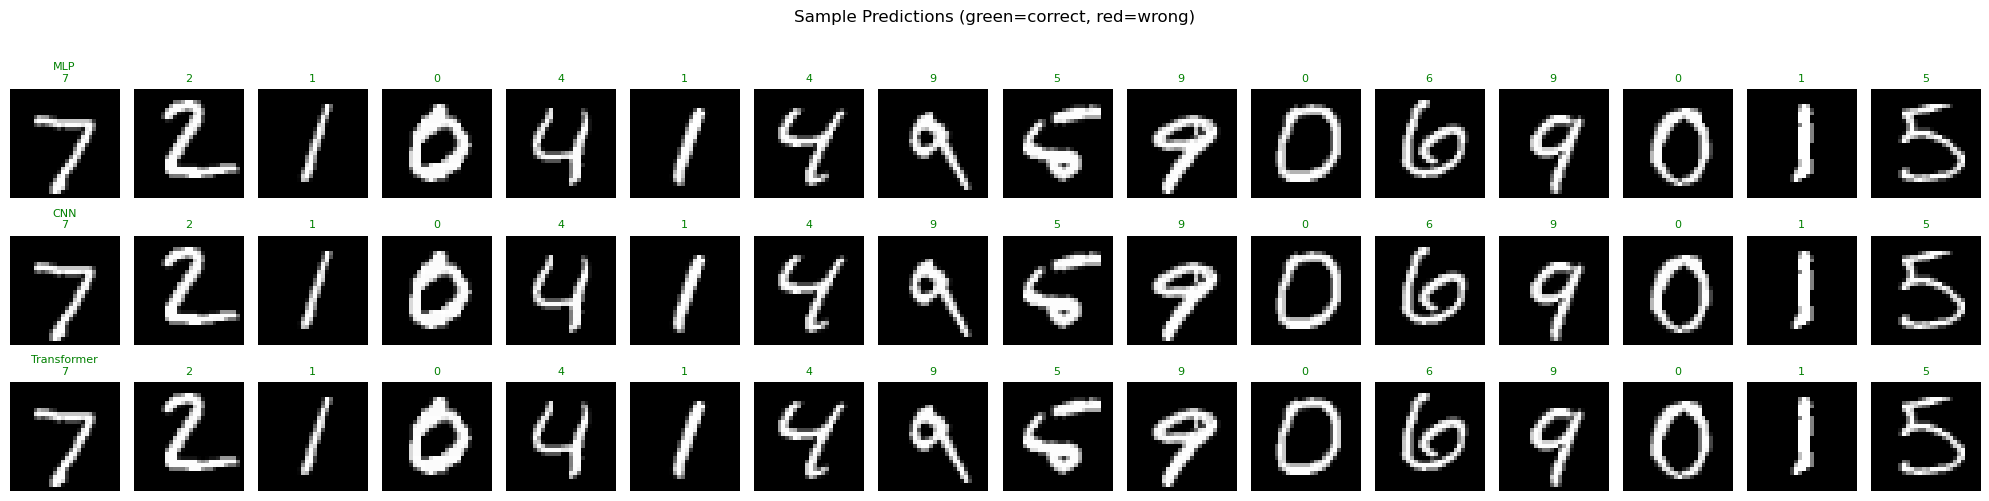

In [16]:
sample_images, sample_labels = next(iter(test_loader))
sample_images_dev = sample_images[:16].to(device)

fig, axes = plt.subplots(3, 16, figsize=(20, 5))
model_list = [("MLP", mlp_model), ("CNN", cnn_model), ("Transformer", transformer_model)]

for row, (name, model) in enumerate(model_list):
    model.eval()
    with torch.no_grad():
        preds = model(sample_images_dev).argmax(1).cpu()
    for col in range(16):
        ax = axes[row, col]
        ax.imshow(sample_images[col].squeeze(), cmap="gray")
        ax.axis("off")
        true_label = sample_labels[col].item()
        pred_label = preds[col].item()
        color = "green" if pred_label == true_label else "red"
        if col == 0:
            ax.set_title(f"{name}\n{pred_label}", fontsize=8, color=color)
        else:
            ax.set_title(str(pred_label), fontsize=8, color=color)

plt.suptitle("Sample Predictions (green=correct, red=wrong)", y=1.02)
plt.tight_layout()
plt.show()

## Misclassified Examples

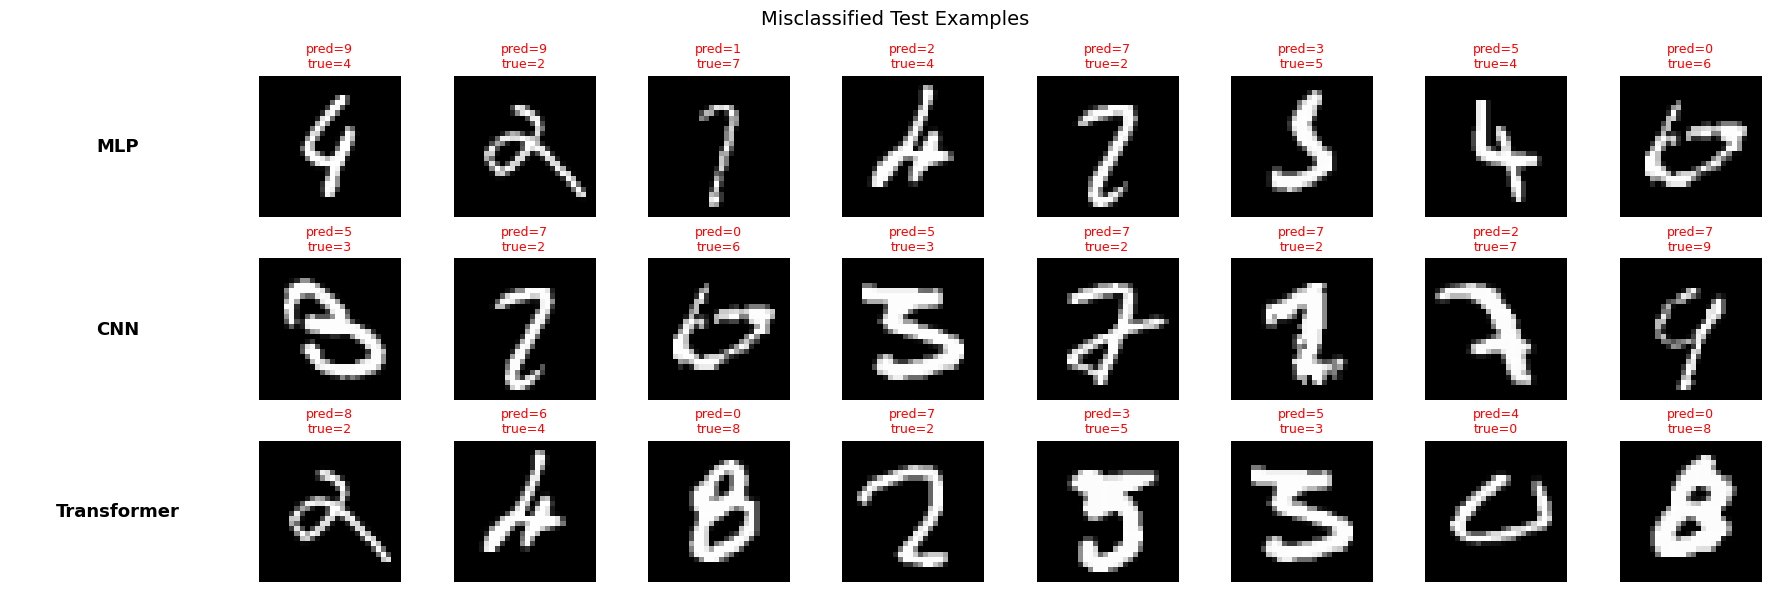

In [17]:
def collect_misclassified(model, test_loader, max_samples=10):
    model.to(device)
    model.eval()
    wrong_images = []
    wrong_preds = []
    wrong_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            mask = preds != labels
            if mask.any():
                wrong_images.append(images[mask].cpu())
                wrong_preds.append(preds[mask].cpu())
                wrong_labels.append(labels[mask].cpu())
            if sum(len(w) for w in wrong_images) >= max_samples:
                break

    return (
        torch.cat(wrong_images)[:max_samples],
        torch.cat(wrong_preds)[:max_samples],
        torch.cat(wrong_labels)[:max_samples],
    )


NUM_EXAMPLES = 8
model_list = [("MLP", mlp_model), ("CNN", cnn_model), ("Transformer", transformer_model)]

fig, axes = plt.subplots(3, NUM_EXAMPLES + 1, figsize=(18, 6),
                          gridspec_kw={"width_ratios": [1.2] + [1] * NUM_EXAMPLES})

for row, (name, model) in enumerate(model_list):
    label_ax = axes[row, 0]
    label_ax.axis("off")
    label_ax.text(0.5, 0.5, name, fontsize=13, fontweight="bold",
                  ha="center", va="center", transform=label_ax.transAxes)

    imgs, preds, labels = collect_misclassified(model, test_loader, max_samples=NUM_EXAMPLES)
    for col in range(min(NUM_EXAMPLES, len(imgs))):
        ax = axes[row, col + 1]
        ax.imshow(imgs[col].squeeze(), cmap="gray")
        ax.set_title(f"pred={preds[col].item()}\ntrue={labels[col].item()}", fontsize=9, color="red")
        ax.axis("off")

plt.suptitle("Misclassified Test Examples", fontsize=14)
plt.tight_layout()
plt.show()

## Confusion Matrix Heatmaps

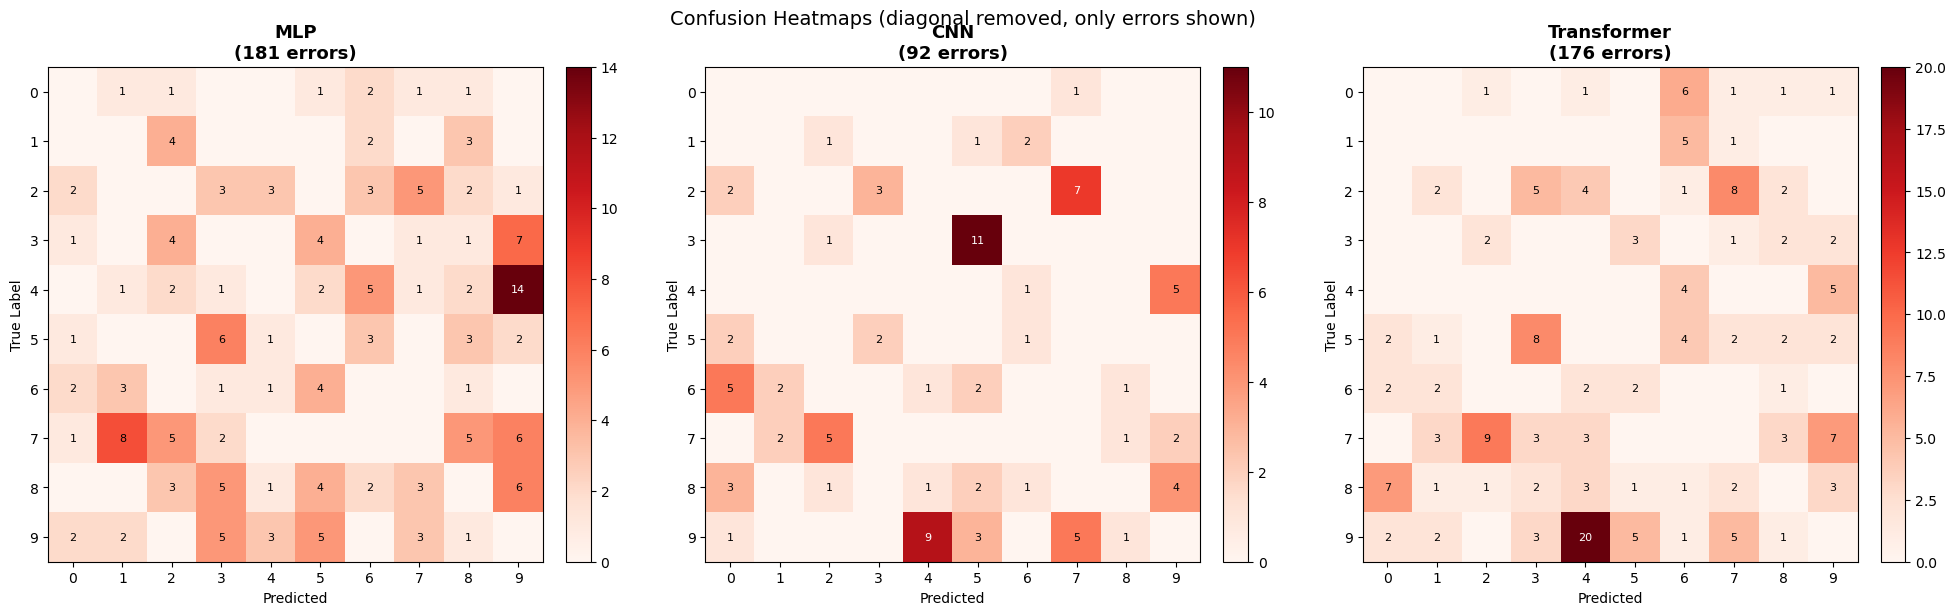

In [20]:
import numpy as np


def build_confusion_matrix(model, test_loader):
    model.to(device)
    model.eval()
    matrix = np.zeros((10, 10), dtype=int)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            for t, p in zip(labels.cpu().numpy(), preds.cpu().numpy()):
                matrix[t][p] += 1

    return matrix


model_list = [("MLP", mlp_model), ("CNN", cnn_model), ("Transformer", transformer_model)]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, model) in zip(axes, model_list):
    cm = build_confusion_matrix(model, test_loader)

    # Zero out the diagonal so only mistakes are visible
    np.fill_diagonal(cm, 0)

    im = ax.imshow(cm, cmap="Reds", interpolation="nearest")
    ax.set_title(f"{name}\n({cm.sum()} errors)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True Label")
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))

    # Annotate each cell with its count
    for i in range(10):
        for j in range(10):
            val = cm[i, j]
            if val > 0:
                ax.text(j, i, str(val), ha="center", va="center",
                        fontsize=8, color="white" if val > cm.max() * 0.6 else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Confusion Heatmaps (diagonal removed, only errors shown)", fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Ensemble Model (Majority Vote)

In [ ]:
def ensemble_predict(models, test_loader):
    """Each model votes via argmax; final prediction is the majority vote."""
    for m in models:
        m.to(device)
        m.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            # Stack each model's argmax prediction: (num_models, batch)
            votes = torch.stack([m(images).argmax(1) for m in models], dim=0)
            # Majority vote via one-hot counting per sample
            one_hot = torch.zeros(votes.shape[1], 10, device=device)
            for v in votes:
                one_hot.scatter_add_(1, v.unsqueeze(1), torch.ones_like(v, dtype=torch.float).unsqueeze(1))
            ensemble_preds = one_hot.argmax(1)

            all_preds.append(ensemble_preds.cpu())
            all_labels.append(labels)

    return torch.cat(all_preds), torch.cat(all_labels)


ensemble_models = [mlp_model, cnn_model, transformer_model]
ens_preds, ens_labels = ensemble_predict(ensemble_models, test_loader)

ens_correct = (ens_preds == ens_labels).sum().item()
ens_total = len(ens_labels)
print(f"Ensemble (MLP + CNN + Transformer) | Test Accuracy: {100.0 * ens_correct / ens_total:.2f}%")
print(f"  Correct: {ens_correct}/{ens_total}")
print(f"  Errors:  {ens_total - ens_correct}")

Ensemble (MLP + CNN + Transformer) -- Test Accuracy: 98.70%
  Correct: 9870/10000
  Errors:  130


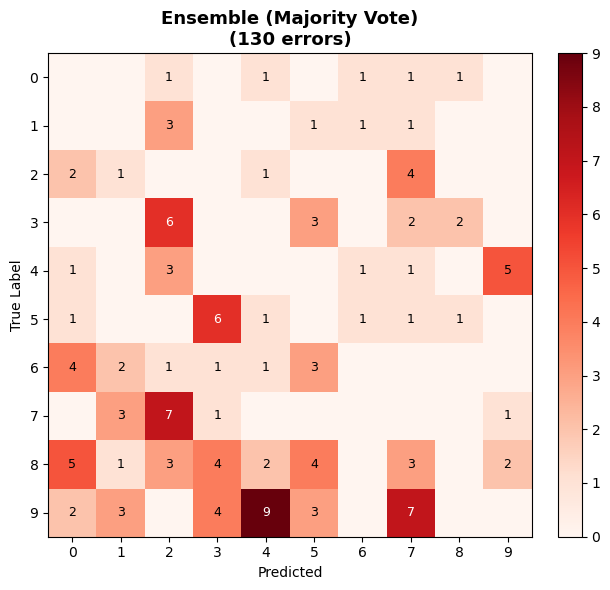

In [ ]:
# Build confusion matrix for ensemble
ens_cm = np.zeros((10, 10), dtype=int)
for t, p in zip(ens_labels.numpy(), ens_preds.numpy()):
    ens_cm[t][p] += 1

np.fill_diagonal(ens_cm, 0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(ens_cm, cmap="Reds", interpolation="nearest")
ax.set_title(f"Ensemble (Majority Vote)\n({ens_cm.sum()} errors)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True Label")
ax.set_xticks(range(10))
ax.set_yticks(range(10))

for i in range(10):
    for j in range(10):
        val = ens_cm[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=9, color="white" if val > ens_cm.max() * 0.6 else "black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()